<a href="https://colab.research.google.com/github/Nizamuddin1N/Collaborative-Real-Time-Code-Editor/blob/main/TwitterSentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install / import

In [ ]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk import download
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Try loading safely, detect malformed header (header row is data)

In [ ]:

file_path = '/twitter_training.csv'
# First try with header=0 (normal)
df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')

# Heuristic: if first row looks like data (e.g. columns are numeric or actual text appears as column names),
# and columns don't include expected names, re-load with header=None
cols_lower = [str(c).lower() for c in df.columns]
print("\nInitial columns detected:", df.columns.tolist())

# If none of the expected column-name tokens appear, assume header was data -> reload with header=None
expected_tokens = ['text', 'tweet', 'brand', 'company', 'message', 'review']
if not any(any(tok in c for tok in expected_tokens) for c in cols_lower):
    print("Header looks like data. Reloading file using header=None ...")
    df = pd.read_csv(file_path, header=None, encoding='utf-8', on_bad_lines='skip')
    print("Reloaded. Columns now:", df.columns.tolist())


Initial columns detected: ['2401', 'Borderlands', 'Positive', 'im getting on borderlands and i will murder you all ,']
Header looks like data. Reloading file using header=None ...
Reloaded. Columns now: [0, 1, 2, 3]


#Standardize / assign column names based on the likely structure

In [ ]:
# Many Twitter training CSVs have 4 columns: id, brand, sentiment, text (your sample).
# If df has >=4 columns, map first 4 to meaningful names. Otherwise try to detect text column.
if df.shape[1] >= 4:
    # assign first 4 columns to id, brand, sentiment, text (safest for your file)
    rename_map = {df.columns[0]:'id', df.columns[1]:'brand', df.columns[2]:'sentiment', df.columns[3]:'text'}
    df = df.rename(columns=rename_map)
else:
    # Try to detect text and brand from column names
    cols = df.columns.tolist()
    cols_low = [str(c).lower() for c in cols]
    # find text column
    text_candidates = [cols[i] for i, c in enumerate(cols_low) if any(tok in c for tok in ['text','tweet','message','review','comment'])]
    brand_candidates = [cols[i] for i, c in enumerate(cols_low) if any(tok in c for tok in ['brand','company','product','name'])]
    if text_candidates:
        df = df.rename(columns={text_candidates[0]:'text'})
    else:
        raise ValueError("Could not detect text column automatically. Please tell me which column holds tweets.")
    if brand_candidates:
        df = df.rename(columns={brand_candidates[0]:'brand'})
    else:
        # If no brand, create a placeholder brand column
        df['brand'] = 'unknown'

print("\nColumns after renaming:", df.columns.tolist())


Columns after renaming: ['id', 'brand', 'sentiment', 'text']


# Keep necessary columns and drop rows without text

In [ ]:
if 'text' not in df.columns:
    raise ValueError("Text column not found after renaming. Inspect df.columns and tell me the text column name.")
df = df[['id','brand','sentiment','text']] if set(['id','brand','sentiment','text']).issubset(df.columns) else df[['brand','text']]

df = df.dropna(subset=['text']).reset_index(drop=True)
print("Dataframe shape after keeping brand & text:", df.shape)

Dataframe shape after keeping brand & text: (73996, 4)


#Cleaning function (safe)

In [ ]:
def clean_text(s):
    s = str(s)
    s = re.sub(r'http\S+', '', s)               # remove URLs
    s = re.sub(r'@\w+', '', s)                  # remove @mentions
    s = re.sub(r'#', '', s)                     # remove hashtag symbol only
    s = re.sub(r'[^A-Za-z\s]', ' ', s)          # remove non-letters (keep spaces)
    s = re.sub(r'\s+', ' ', s)                  # collapse whitespace
    return s.strip().lower()

df['clean_text'] = df['text'].apply(clean_text)

print("\nSample cleaned text:")
display(df[['text','clean_text']].head(6))


Sample cleaned text:


,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...


#VADER sentiment (download lexicon if needed)

In [ ]:
download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# compute scores column-wise in a vectorized apply (safe)
scores = df['clean_text'].apply(lambda t: sia.polarity_scores(t))
df['compound'] = scores.apply(lambda s: s['compound'])
df['neg'] = scores.apply(lambda s: s['neg'])
df['neu'] = scores.apply(lambda s: s['neu'])
df['pos'] = scores.apply(lambda s: s['pos'])

# label
df['vader_sentiment'] = df['compound'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))

print("\nVADER sentiment counts:")
print(df['vader_sentiment'].value_counts())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!



VADER sentiment counts:
vader_sentiment
positive    34338
negative    27151
neutral     12507
Name: count, dtype: int64


#Visualizations (overall + brand-wise)

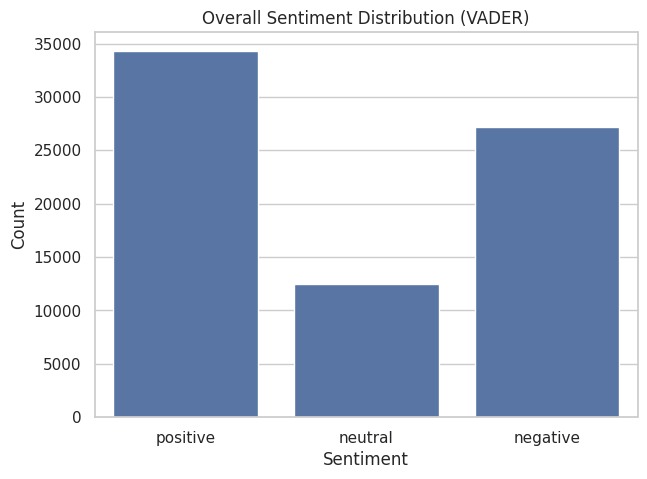


Top brands found (counts):
brand
LeagueOfLegends              2377
MaddenNFL                    2377
CallOfDuty                   2376
Verizon                      2365
TomClancysRainbowSix         2364
Facebook                     2362
Microsoft                    2361
Dota2                        2359
WorldOfCraft                 2357
ApexLegends                  2353
NBA2K                        2343
CallOfDutyBlackopsColdWar    2343
johnson&johnson              2324
FIFA                         2324
TomClancysGhostRecon         2321
Overwatch                    2316
Battlefield                  2316
GrandTheftAuto(GTA)          2293
HomeDepot                    2292
PlayStation5(PS5)            2291
Name: count, dtype: int64


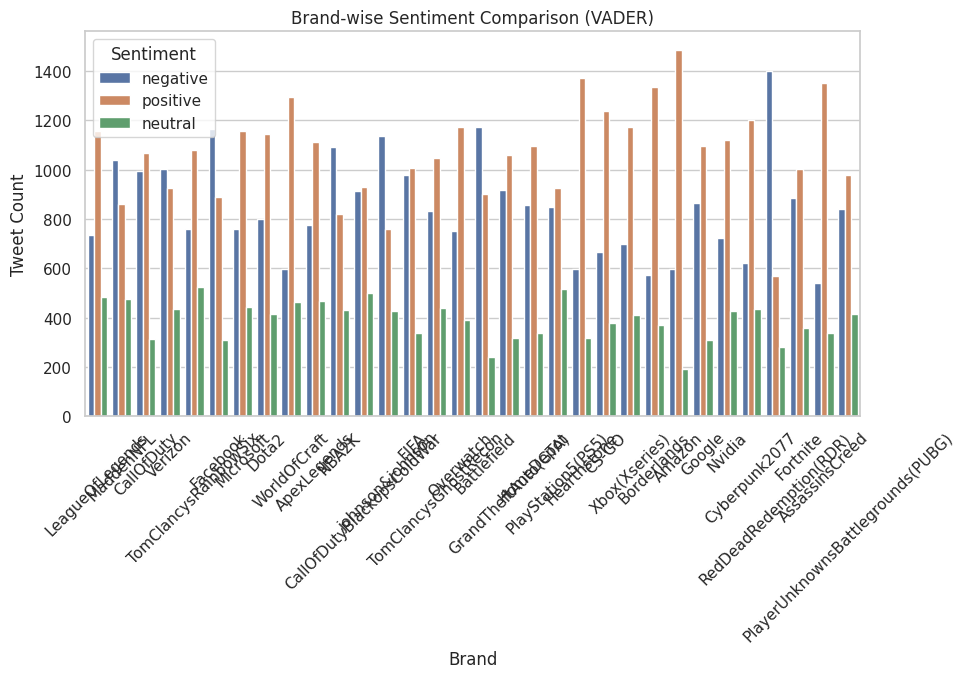

In [ ]:
sns.set(style="whitegrid")

# Overall distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='vader_sentiment', order=['positive','neutral','negative'])
plt.title('Overall Sentiment Distribution (VADER)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Brand-wise comparison — ensure brand is categorical and not too many unique values
brand_counts = df['brand'].value_counts()
print("\nTop brands found (counts):")
print(brand_counts.head(20))

top_brands = brand_counts[brand_counts >= 5].index.tolist()  # only brands with >=5 tweets to show
if len(top_brands) == 0:
    top_brands = brand_counts.index.tolist()[:8]  # fallback to top 8

plt.figure(figsize=(10,5))
sns.countplot(data=df[df['brand'].isin(top_brands)], x='brand', hue='vader_sentiment', order=top_brands)
plt.title('Brand-wise Sentiment Comparison (VADER)')
plt.xlabel('Brand')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()

#Optional: WordClouds for each sentiment (install might be needed)

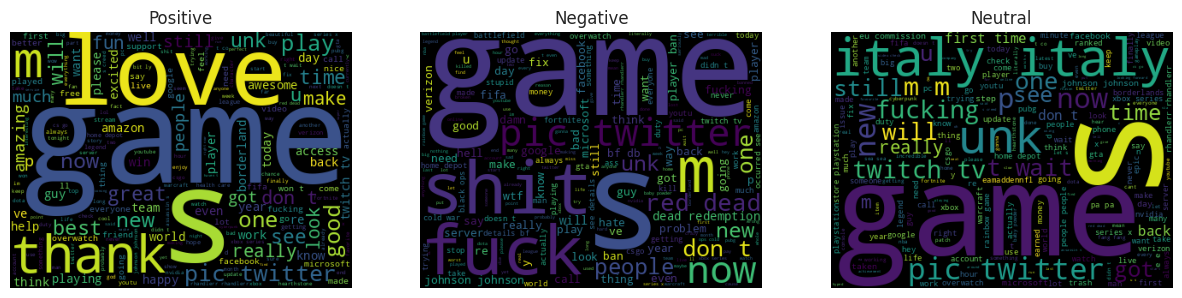

In [ ]:
try:
    from wordcloud import WordCloud
    pos_text = ' '.join(df[df['vader_sentiment']=='positive']['clean_text'].tolist())
    neg_text = ' '.join(df[df['vader_sentiment']=='negative']['clean_text'].tolist())
    neu_text = ' '.join(df[df['vader_sentiment']=='neutral']['clean_text'].tolist())

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(WordCloud(width=400, height=300).generate(pos_text))
    plt.axis('off'); plt.title('Positive')

    plt.subplot(1,3,2)
    plt.imshow(WordCloud(width=400, height=300).generate(neg_text))
    plt.axis('off'); plt.title('Negative')

    plt.subplot(1,3,3)
    plt.imshow(WordCloud(width=400, height=300).generate(neu_text))
    plt.axis('off'); plt.title('Neutral')

    plt.show()
except Exception as e:
    print("WordCloud not generated (install wordcloud to enable). Error:", e)

#Save cleaned dataset

In [ ]:
out_name = "cleaned_twitter_training.csv"
df.to_csv(out_name, index=False)
print("\nSaved cleaned output to:", out_name)


Saved cleaned output to: cleaned_twitter_training.csv
